# Final Assignment : Logistic Regression and Weighted Logistic Regression


## Basic information about the dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score,precision_recall_curve

In [2]:
ccf = pd.read_csv('/content/credit_card_fraud_10k.csv')

In [3]:
print(ccf.head())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [4]:
ccf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [5]:
print(ccf.describe())

       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
min             0.000000     

In [6]:
ccf.drop(columns=['transaction_id'], inplace=True)

In [7]:
ccf.shape

(10000, 9)

## Data Cleaning

In [8]:
ccf_copy = ccf.copy()

In [9]:
print(f'Number of dublicate rows are: {ccf_copy.duplicated().sum()}')

Number of dublicate rows are: 0


In [10]:
print(f'Number of null values in the dataset:\n{ccf_copy.isnull().sum()}')

Number of null values in the dataset:
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


In [11]:
num_cols = ccf_copy.select_dtypes(include = ['int64','float64']).columns
num_cols = num_cols.drop('is_fraud')

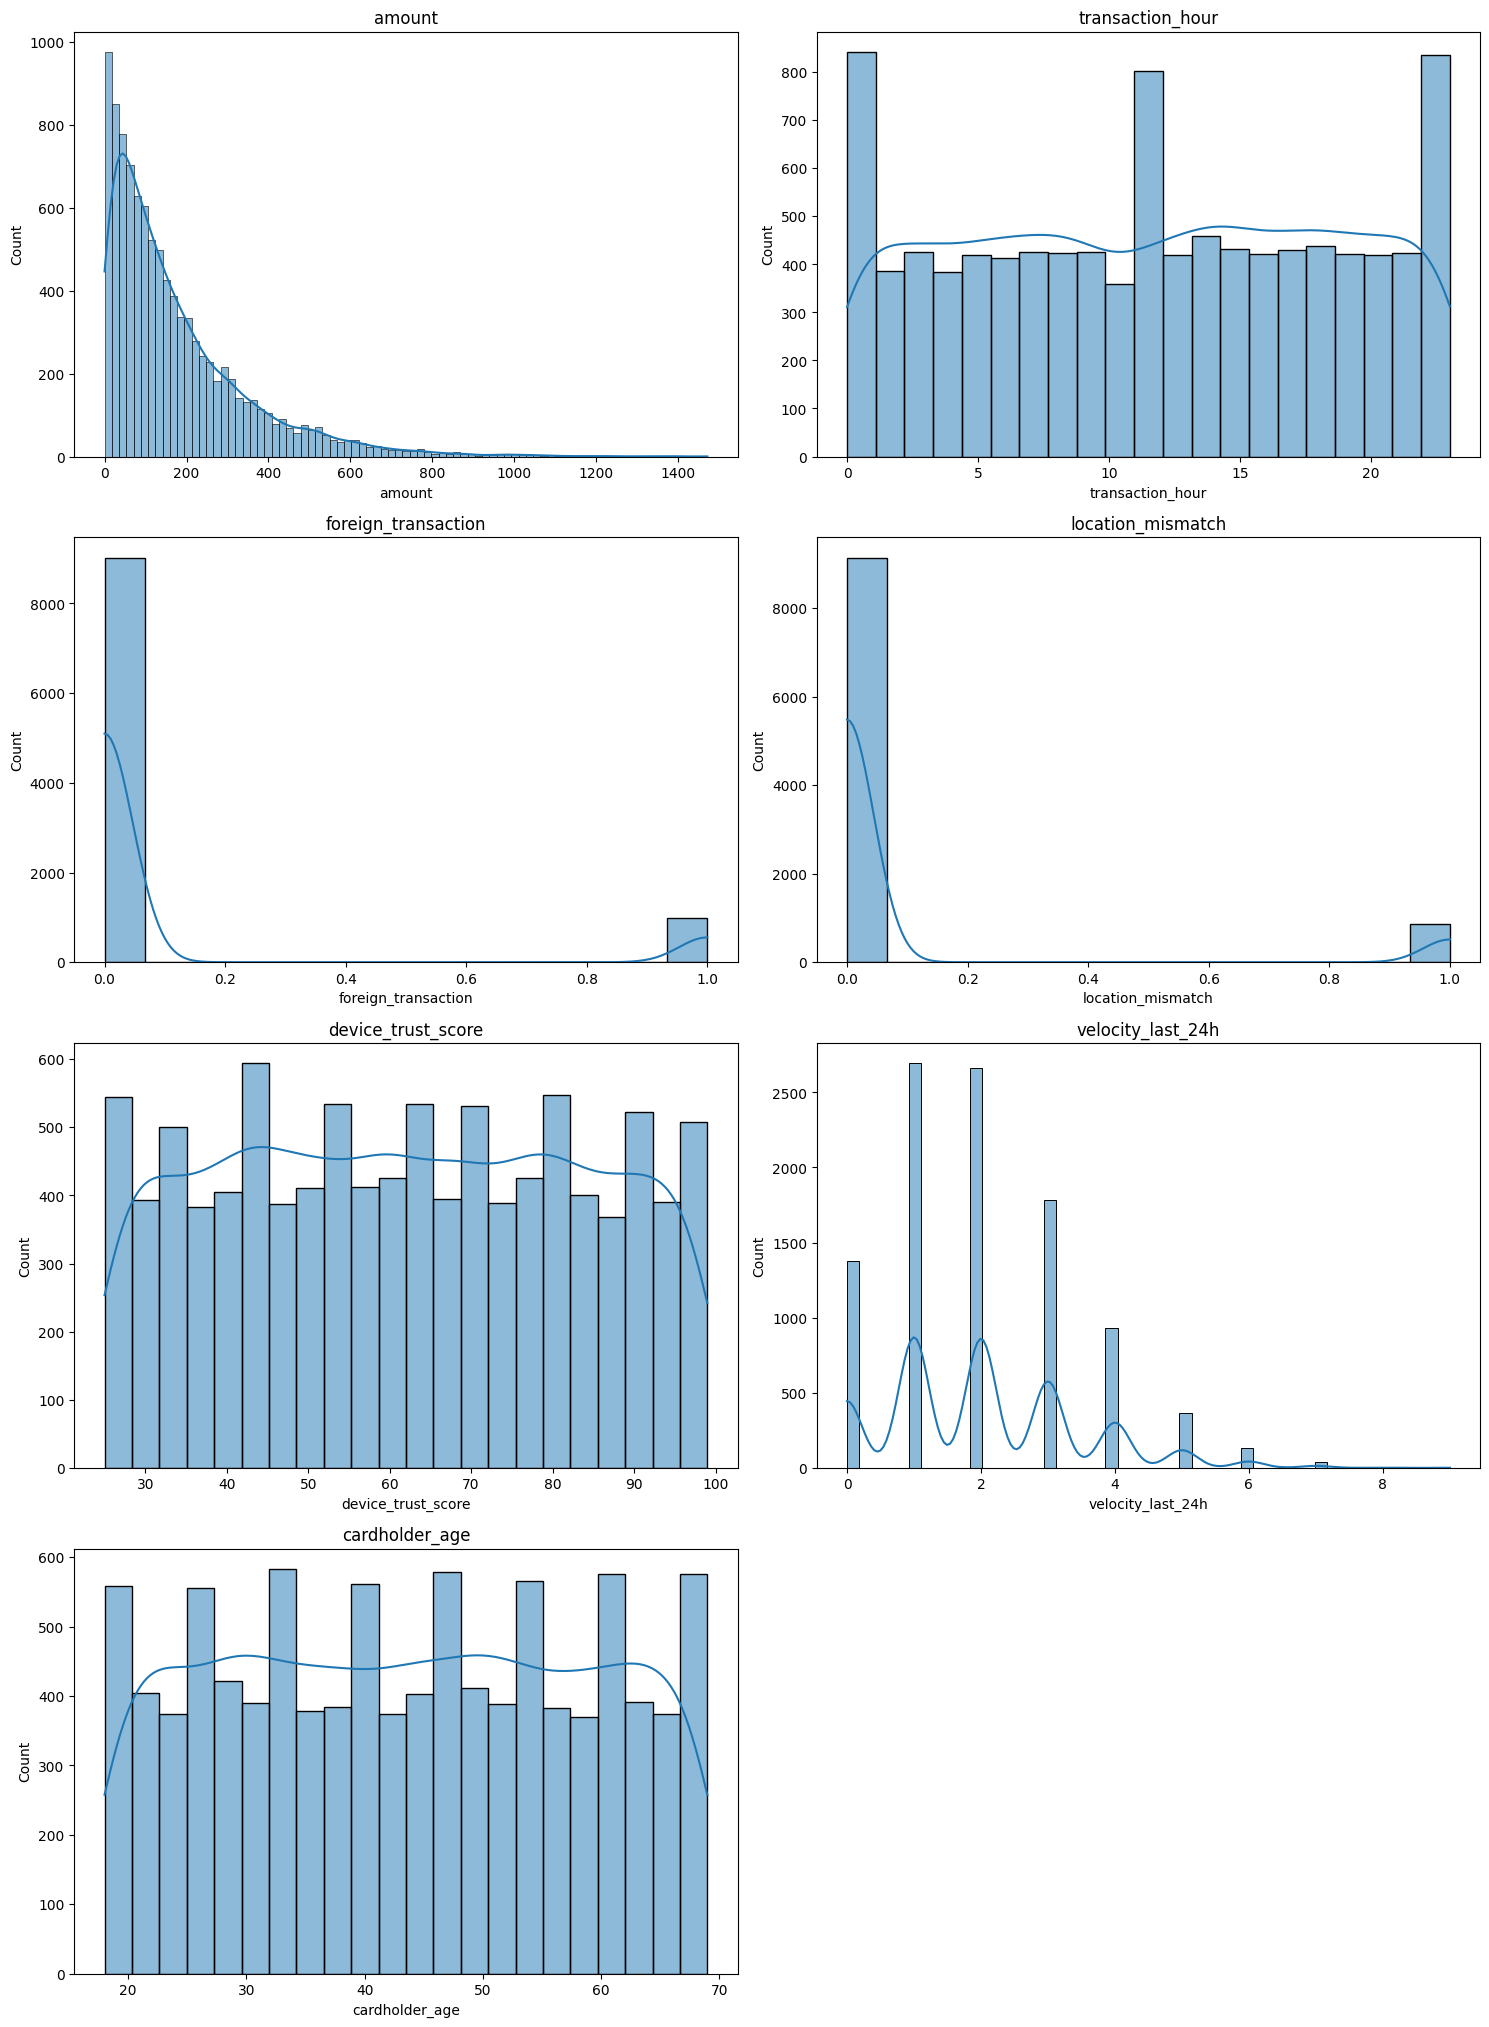

In [12]:
plt.figure(figsize=(15, 25))

for i, col in enumerate(num_cols, start=1):
    plt.subplot(5, 2, i)
    sns.histplot(ccf_copy[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

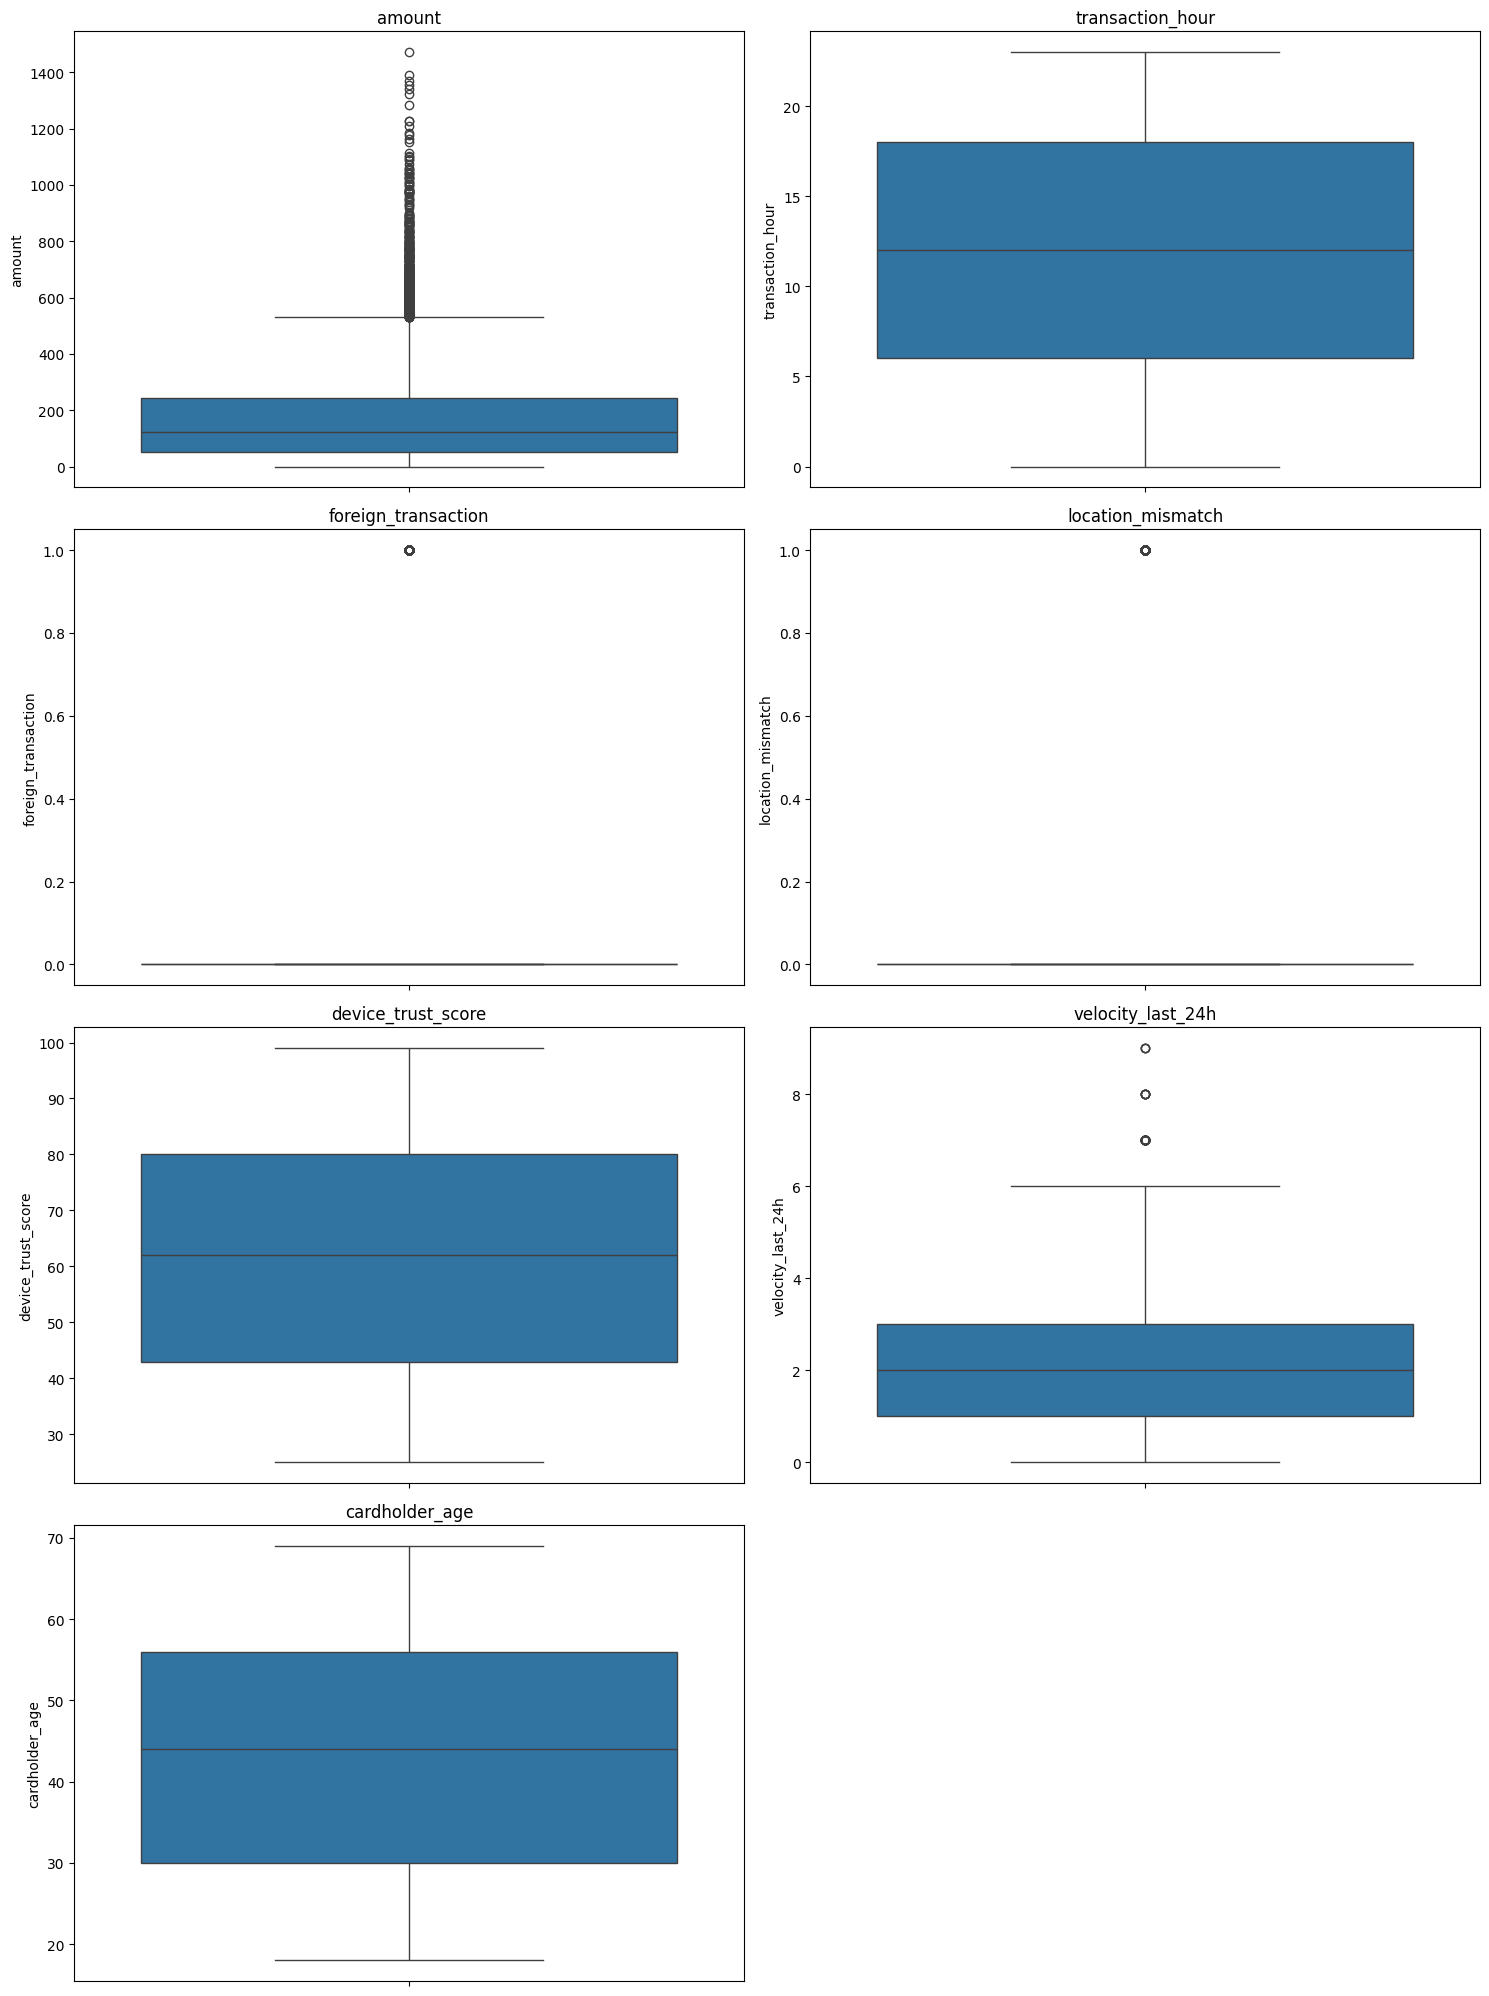

In [13]:
plt.figure(figsize=(15, 25))

for i, col in enumerate(num_cols, start=1):
    plt.subplot(5, 2, i)
    sns.boxplot(ccf_copy[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [14]:
ccf_copy[num_cols].skew()

,0
amount,1.919265
transaction_hour,-0.026581
foreign_transaction,2.708422
location_mismatch,2.960570
device_trust_score,0.011191
velocity_last_24h,0.707884
cardholder_age,0.003868


In [15]:
ccf_copy['is_fraud'].value_counts() * 100

,count
is_fraud,
0,984900
1,15100


## Data Preprocessing

In [16]:
# Separating dataset into X and y
X = ccf_copy.drop(columns=['is_fraud'])  # example target
y = ccf_copy['is_fraud']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
# Log transformation to reduce skewness
X_train['amount'] = np.log1p(X_train['amount'])
X_test['amount']  = np.log1p(X_test['amount'])

In [19]:
X_train[num_cols].skew()

,0
amount,-0.787350
transaction_hour,-0.027348
foreign_transaction,2.695231
location_mismatch,2.976731
device_trust_score,-0.000353
velocity_last_24h,0.708300
cardholder_age,0.002899


In [20]:
num_cols = num_cols.drop(['foreign_transaction','location_mismatch'])

In [21]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [22]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train[['merchant_category']]),
    columns=encoder.get_feature_names_out(['merchant_category']),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test[['merchant_category']]),
    columns=encoder.get_feature_names_out(['merchant_category']),
    index=X_test.index
)

# Concatenate with numerical columns
X_train_final = pd.concat([X_train[:], X_train_cat], axis=1)
X_test_final  = pd.concat([X_test[:], X_test_cat], axis=1)

In [23]:
X_train_final.drop(columns=['merchant_category'], inplace=True)
X_test_final.drop(columns=['merchant_category'], inplace=True)

## Model Training and Evaluation Matrices

### Standard Logistic Regression

In [24]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_final, y_train)

y_pred = log_reg.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :",recall_score(y_test, y_pred))
print("F1 Score :",f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.993
Precision: 0.9444444444444444
Recall   : 0.5666666666666667
F1 Score : 0.7083333333333334

Confusion Matrix:
 [[1969    1]
 [  13   17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.94      0.57      0.71        30

    accuracy                           0.99      2000
   macro avg       0.97      0.78      0.85      2000
weighted avg       0.99      0.99      0.99      2000



### Weighted Logistic Regression

In [25]:
n0 = np.sum(y_train == 0)
n1 = np.sum(y_train == 1)

w0 = len(y_train) / (2 * n0)
w1 = len(y_train) / (2 * n1)

print("Class weights:", w0, w1)

Class weights: 0.5076786394212464 33.05785123966942


In [26]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def compute_gradients(X, y, y_hat,w0,w1):
    m = len(y)
    weights = np.where(y == 1, w1, w0)
    dw = (1 / m) * np.dot(X.T, weights * (y_hat - y))
    db = (1 / m) * np.sum(weights * (y_hat - y))
    return dw, db
def train_weighted_logistic_regression(X, y, lr=0.005, epochs=6000,w0=w0,w1=w1):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    for _ in range(epochs):
        z = np.dot(X, w) + b
        y_hat = sigmoid(z)
        dw, db = compute_gradients(X, y, y_hat,w0,w1)
        w -= lr * dw
        b -= lr * db
    return w, b


In [27]:
w_weighted, b_weighted = train_weighted_logistic_regression(
    X_train_final,
    y_train
)

In [28]:
y_proba = sigmoid(np.dot(X_test_final, w_weighted) + b_weighted)
y_pred  = (y_proba >= 0.5).astype(int)

In [29]:
print("\nManual Weighted Logistic Regression\n")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Manual Weighted Logistic Regression

Accuracy : 0.863
Precision: 0.09868421052631579
Recall   : 1.0
F1 Score : 0.17964071856287425

Confusion Matrix:
[[1696  274]
 [   0   30]]


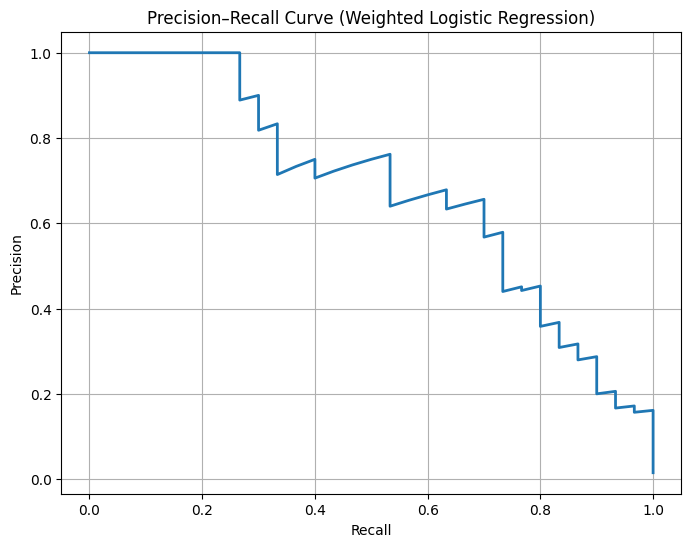

In [33]:


precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(reall := recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Weighted Logistic Regression)")
plt.grid()
plt.show()

In [34]:
# Find thresholds where recall >= 0.80
target_recall = 0.80

valid_idx = np.where(recall >= target_recall)[0]

# precision_recall_curve returns one extra recall value
# thresholds has length = len(recall) - 1
valid_idx = valid_idx[valid_idx < len(thresholds)]

best_idx = valid_idx[-1]   # highest threshold satisfying recall ≥ 0.80
best_threshold = thresholds[best_idx]

print("Threshold for at least 80% recall:", best_threshold)
print("Precision at this threshold:", precision[best_idx])
print("Recall at this threshold:", recall[best_idx])

Threshold for at least 80% recall: 0.8152703176285074
Precision at this threshold: 0.4528301886792453
Recall at this threshold: 0.8


In [35]:
y_pred_80_recall = (y_proba >= best_threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_80_recall))

print("\nFraud Precision:", precision_score(y_test, y_pred_80_recall))
print("Fraud Recall   :", recall_score(y_test, y_pred_80_recall))
print("Fraud F1       :", f1_score(y_test, y_pred_80_recall))

Confusion Matrix:
[[1941   29]
 [   6   24]]

Fraud Precision: 0.4528301886792453
Fraud Recall   : 0.8
Fraud F1       : 0.5783132530120482
